In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize, theory, cluster_utils, torch, data
import torch.nn.functional as F

%load_ext autoreload
%autoreload 2

local_path = '/Users/haozheshan/Dropbox/codes/gp_continual_learning/cluster_results'

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = [1.8, 1.5]
plt.rcParams.update({'font.size': 6})
plt.rcParams['lines.linewidth'] = 1

organizer =\
    cluster_utils.ClusterResultOrganizer(local_path, batch_name='Langevin_5x100_mnist_1L_1.0_N2000')
organizer.load_all()
organize_key = 'l2'
all_test_acc = organizer.organize_results('test acc', organize_key)
all_train_acc = organizer.organize_results('train acc', organize_key)
# all_test_var = organizer.organize_results('test var', organize_key)
# all_train_var = organizer.organize_results('train var', organize_key)
all_test_loss = organizer.organize_results('test loss', organize_key)
all_train_loss = organizer.organize_results('train loss', organize_key)
all_nn_preds = organizer.organize_results('sampled outputs', organize_key)

title_text = f'{organizer.args.dataset}, P={organizer.args.P},' +\
          f'\n {organizer.args.n_tasks} tasks,' \
          f' permutation:{bool(organizer.args.permutation)},' \
          f'Depth:{organizer.args.depth}, N:{organizer.args.N}'

args = organizer.args

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
=================== Cluster organizer ===================
16 data objects loaded from folder "Langevin_5x100_mnist_1L_1.0_N2000".
=================== Cluster organizer ===================


In [33]:
torch.manual_seed(0)

seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit = \
    data.prepare_sequential_dataset(args.n_tasks, args.P, args.P_test,
                                    dataset_name=args.dataset, resample=False,
                                    permutation=args.permutation, data_path=None, precision=32)
seq_of_train_y_onehot = [F.one_hot(digit.long(), num_classes=10) for digit in seq_of_train_y_digit]
seq_of_test_y_onehot = [F.one_hot(digit.long(), num_classes=10) for digit in seq_of_test_y_digit]

seq_of_train_x = seq_of_train_x
seq_of_test_x = seq_of_test_x
seq_of_train_y_onehot = torch.stack(seq_of_train_y_onehot)[:, :, [0]]
seq_of_test_y_onehot = torch.stack(seq_of_test_y_onehot)[:, :, [0]]

train_y_for_theory = seq_of_train_y_onehot.double()

_, theory_test_preds =\
 theory.compute_mean_predictions(seq_of_train_x.double(),
                                 train_y_for_theory[:, :, [0]].double(),
                                 args.sigma**2,
                                 args.P_test,
                                 args.depth,
                                 1e8,
                                 seq_of_test_x.double(), fix_weights=False,
                                 use_naive_gp=False)

_, theory_test_preds_naive =\
theory.compute_mean_predictions(seq_of_train_x.double(),
                                train_y_for_theory[:, :, [0]].double(),
                                args.sigma**2,
                                args.P_test,
                                args.depth,
                                1e8,
                                seq_of_test_x.double(), fix_weights=False,
                                use_naive_gp=True)

/Users/haozheshan/Dropbox/codes/gp_continual_learning/data.py:214: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(dataset.targets).float()
/Users/haozheshan/Dropbox/codes/gp_continual_learning/theory.py:380: UserWarning: arccosine kernel computation is assuming that all inputs have the same norm.
  warnings.warn('arccosine kernel computation is assuming that all inputs have the same norm.')


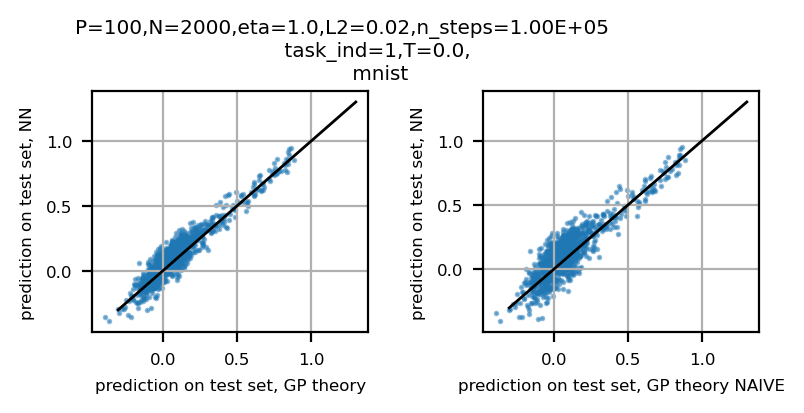

In [38]:
TIME_IND = 1
assert TIME_IND <= args.n_tasks - 1

# plot predictions from head#0 of the NN and that from the theory, on the first test set
fig, axes = plt.subplots(figsize=(4, 2), ncols=2, nrows=1, dpi=200)
axes = axes.ravel()
plt.sca(axes[0])
plt.scatter(all_nn_preds['0.02'].mean(0)[TIME_IND].mean(0),
            theory_test_preds[0, TIME_IND].flatten(), s=1, alpha=0.5)
plt.plot([-0.3, 1.3], [-0.3, 1.3], color='k')
plt.grid()
plt.xlabel('prediction on test set, GP theory')
plt.ylabel('prediction on test set, NN')

plt.sca(axes[1])
plt.scatter(all_nn_preds['0.02'].mean(0)[TIME_IND].mean(0),
            theory_test_preds_naive[0, TIME_IND].flatten(), s=1, alpha=0.5)
plt.plot([-0.3, 1.3], [-0.3, 1.3], color='k')
plt.grid()
plt.xlabel('prediction on test set, GP theory NAIVE')
plt.ylabel('prediction on test set, NN')
plt.suptitle(f'P={args.P},N={args.N},eta={args.eta},L2={args.l2},n_steps={args.n_steps:.2E} \
          \n task_ind={TIME_IND},T={args.T}, \n {args.dataset}')
plt.tight_layout()
plt.subplots_adjust(top=0.8)

Text(0, 0.5, 'test loss')

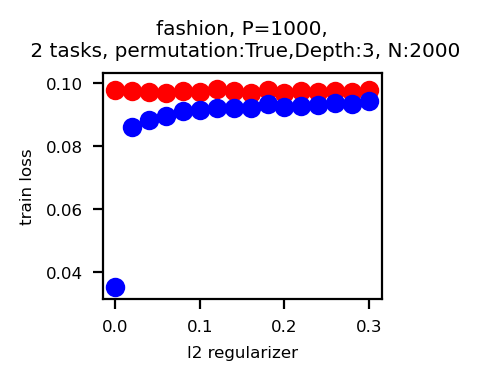

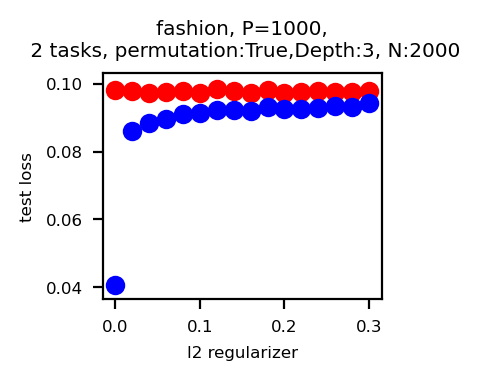

In [33]:
def plot_loss_over_lambda(all_xxx_loss):

    plt.figure()
    for key in all_test_acc.keys():
        plt.errorbar(float(key), all_xxx_loss[key].mean(0)[0, 1],
                     all_xxx_loss[key].std(0)[0, 1], color='r', marker='o')
        plt.errorbar(float(key), all_xxx_loss[key].mean(0)[1, 1],
                     all_xxx_loss[key].std(0)[1, 1], color='b', marker='o')
    plt.xlabel('l2 regularizer')
    plt.title(title_text)


plot_loss_over_lambda(all_train_loss); plt.ylabel('train loss')

plot_loss_over_lambda(all_test_loss); plt.ylabel('test loss')

Text(0.5, 1.0, 'train loss \nfashion, P=1000,\n 2 tasks, permutation:True,Depth:3, N:2000')

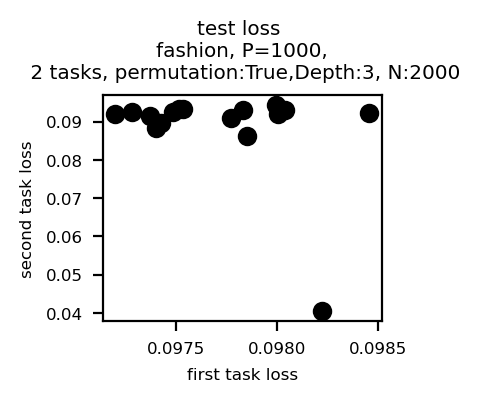

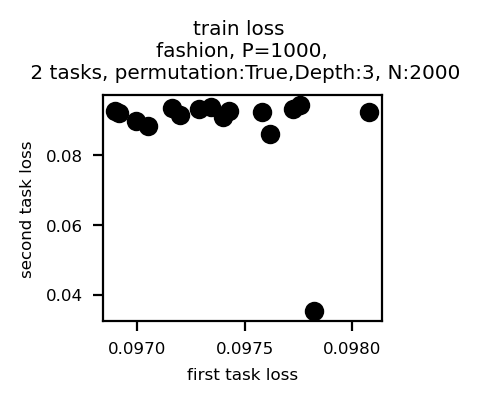

In [34]:
def plot_loss_on_2d(all_xxx_loss):

    plt.figure()
    for key in all_test_acc.keys():
        plt.scatter(all_xxx_loss[key].mean(0)[0, 1], all_xxx_loss[key].mean(0)[1, 1],
                     color='k', marker='o')
    plt.xlabel('first task loss')
    plt.ylabel('second task loss')

plot_loss_on_2d(all_test_loss)
plt.title('test loss \n' + title_text)

plot_loss_on_2d(all_train_loss)
plt.title('train loss \n' + title_text)
